# Evaluación del modelo de xG

## 1. ¿Qué esta evaluando?

El **expected goals (xG)** asigna a cada ocasión una probabilidad de terminar en gol según sus características. La suma de esas probabilidades resume cuánto peligro produjo un equipo; no intenta reconstruir exactamente el marcador.

- **xG predicho:** expectativa ofensiva generada por el modelo antes del partido.
- **xG observado:** calidad acumulada de las ocasiones que realmente se produjeron.
- **Goles observados:** resultado final de esas ocasiones, más sensible a la definición y al rendimiento del portero.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11.5,
    "axes.titleweight": "bold",
})


def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)


def finish_chart(fig, subtitle, y=0.93):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")
    fig.text(0.975, 0.975, "✦", fontsize=17, color=GOLD, ha="right", va="top")


data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

SOURCE_PATH = DATA_DIR / "predictions.xlsx"
raw_predictions = pd.read_excel(SOURCE_PATH)

required_columns = [
    "match_id", "home_team", "away_team", "match_date", "league",
    "proj_home_xg", "proj_away_xg", "home_xg", "away_xg",
    "home_goals", "away_goals",
]
missing_columns = set(required_columns) - set(raw_predictions.columns)
assert not missing_columns, f"Faltan columnas requeridas: {sorted(missing_columns)}"

predictions = raw_predictions[required_columns].copy()
predictions["match_date"] = pd.to_datetime(predictions["match_date"])
complete_predictions = predictions.dropna().copy()

assert raw_predictions["match_id"].is_unique
assert complete_predictions["match_id"].is_unique
assert complete_predictions[required_columns].notna().all().all()
assert (complete_predictions[["proj_home_xg", "proj_away_xg", "home_xg", "away_xg"]] >= 0).all().all()
assert (complete_predictions[["home_goals", "away_goals"]] >= 0).all().all()

coverage = pd.DataFrame({
    "Indicador": [
        "Partidos en el archivo",
        "Partidos completos",
        "Partidos excluidos por xG faltante",
        "Predicciones equipo-partido",
        "Ligas",
        "Periodo",
    ],
    "Valor": [
        f"{len(raw_predictions):,}",
        f"{len(complete_predictions):,}",
        f"{len(raw_predictions) - len(complete_predictions):,}",
        f"{2 * len(complete_predictions):,}",
        f"{complete_predictions['league'].nunique():,}",
        f"{complete_predictions['match_date'].min():%d/%m/%Y} – {complete_predictions['match_date'].max():%d/%m/%Y}",
    ],
})

display(coverage.set_index("Indicador"))

,Valor
Indicador,
Partidos en el archivo,485
Partidos completos,476
Partidos excluidos por xG faltante,9
Predicciones equipo-partido,952
Ligas,8
Periodo,03/01/2025 – 27/04/2025


La comparación se limita a los partidos que contienen predicción, xG observado y marcador para ambos equipos. Los nueve encuentros sin xG observado se conservan en el archivo fuente, pero no entran en las métricas.

## 2. Diez partidos antes de mirar los promedios

Una métrica resume cientos de predicciones, pero no muestra cómo se ve un partido concreto. Las siguientes diez filas se sortean con una semilla fija (`42`): son reproducibles y no fueron elegidas por ser especialmente buenas o malas.

In [2]:
EXAMPLE_SEED = 42

example_matches = (
    complete_predictions
    .sample(n=10, random_state=EXAMPLE_SEED)
    .sort_values(["match_date", "match_id"])
    .copy()
)
example_matches["mean_abs_xg_error"] = (
    (example_matches["proj_home_xg"] - example_matches["home_xg"]).abs()
    + (example_matches["proj_away_xg"] - example_matches["away_xg"]).abs()
) / 2

example_table = pd.DataFrame({
    "Fecha": example_matches["match_date"].dt.strftime("%d/%m/%Y"),
    "Partido": example_matches["home_team"] + " – " + example_matches["away_team"],
    "Liga": example_matches["league"],
    "xG predicho": example_matches.apply(lambda row: f"{row['proj_home_xg']:.2f} – {row['proj_away_xg']:.2f}", axis=1),
    "xG observado": example_matches.apply(lambda row: f"{row['home_xg']:.2f} – {row['away_xg']:.2f}", axis=1),
    "Marcador": example_matches.apply(lambda row: f"{int(row['home_goals'])} – {int(row['away_goals'])}", axis=1),
    "Error medio xG": example_matches["mean_abs_xg_error"].round(3),
})

display(example_table.reset_index(drop=True))

,Fecha,Partido,Liga,xG predicho,xG observado,Marcador,Error medio xG
0,04/01/2025,Lille – Nantes,Ligue 1,1.41 – 0.60,1.19 – 1.33,1 – 1,0.475
1,04/01/2025,Benfica – Braga,Primeira Liga,1.80 – 0.93,1.63 – 0.73,1 – 2,0.185
2,11/01/2025,Alavés – Girona,La Liga,0.85 – 1.59,1.31 – 0.50,0 – 1,0.775
3,25/01/2025,Como – Atalanta,Serie A,1.35 – 1.67,0.77 – 0.96,1 – 2,0.645
4,27/01/2025,Genoa – Monza,Serie A,1.26 – 0.82,2.66 – 0.43,2 – 0,0.895
5,14/02/2025,Boavista – Estrela,Primeira Liga,1.25 – 1.21,0.51 – 0.47,0 – 1,0.740
6,15/02/2025,Aston Villa – Ipswich Town,Premier League,1.55 – 0.83,2.47 – 0.37,1 – 1,0.690
7,15/02/2025,Willem II – Groningen,Eredivisie,0.65 – 1.15,1.06 – 1.95,1 – 3,0.605
8,31/03/2025,Celta Vigo – Las Palmas,La Liga,1.86 – 0.53,0.97 – 0.33,1 – 1,0.545
9,05/04/2025,Mainz 05 – Holstein Kiel,Bundesliga,1.34 – 1.17,1.86 – 0.95,1 – 1,0.370


El marcador y el xG pueden contar historias distintas. Un equipo puede generar mejores ocasiones y aun así marcar menos: por eso el xG observado es la referencia más directa para evaluar la expectativa ofensiva del modelo.

## 3. Tres comparaciones, tres preguntas

1. **Modelo → xG observado:** ¿anticipa la calidad de las ocasiones que producirá cada equipo?
2. **Modelo → goles:** ¿qué tan cerca queda del marcador, incluyendo la variación de la definición?
3. **xG observado → goles:** ¿qué tan cerca queda la propia medida de ocasiones del marcador? Esta tercera comparación es una referencia, no otro modelo prepartido.

**MAE** es la distancia promedio; **RMSE** castiga más los errores grandes. En ambos casos, menor es mejor. **R²** indica qué proporción de la variación captura la relación; mayor es mejor y puede ser negativo.

In [3]:
home_observations = complete_predictions.rename(columns={
    "home_team": "team",
    "proj_home_xg": "predicted_xg",
    "home_xg": "observed_xg",
    "home_goals": "observed_goals",
})[["match_id", "match_date", "league", "team", "predicted_xg", "observed_xg", "observed_goals"]].assign(side="Local")

away_observations = complete_predictions.rename(columns={
    "away_team": "team",
    "proj_away_xg": "predicted_xg",
    "away_xg": "observed_xg",
    "away_goals": "observed_goals",
})[["match_id", "match_date", "league", "team", "predicted_xg", "observed_xg", "observed_goals"]].assign(side="Visitante")

team_observations = pd.concat([home_observations, away_observations], ignore_index=True)


def regression_metrics(observed, estimated):
    return {
        "MAE": mean_absolute_error(observed, estimated),
        "RMSE": np.sqrt(mean_squared_error(observed, estimated)),
        "R²": r2_score(observed, estimated),
    }


metric_specs = [
    ("Modelo → xG", team_observations["observed_xg"], team_observations["predicted_xg"]),
    ("Modelo → goles", team_observations["observed_goals"], team_observations["predicted_xg"]),
    ("xG → goles", team_observations["observed_goals"], team_observations["observed_xg"]),
]

metrics = pd.DataFrame(
    [{"Comparación": label, **regression_metrics(observed, estimated)} for label, observed, estimated in metric_specs]
).set_index("Comparación")

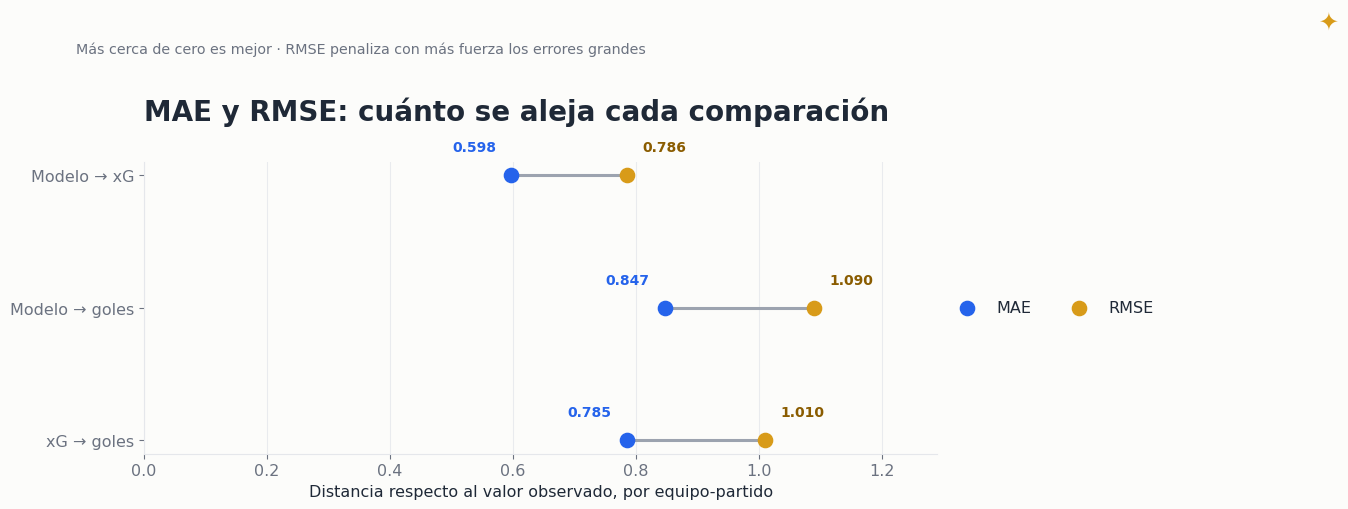

In [4]:
comparison_labels = metrics.index.tolist()
y_positions = np.arange(len(comparison_labels))[::-1]

fig, ax = plt.subplots(figsize=(13.8, 5.2))

for y, label in zip(y_positions, comparison_labels):
    mae = metrics.loc[label, "MAE"]
    rmse = metrics.loc[label, "RMSE"]
    ax.plot([mae, rmse], [y, y], color=GREY, linewidth=2.2, zorder=1)
    ax.scatter(mae, y, s=105, color=BLUE, marker="o", label="MAE" if y == y_positions[0] else None, zorder=2)
    ax.scatter(rmse, y, s=105, color=GOLD, marker="o", label="RMSE" if y == y_positions[0] else None, zorder=2)
    ax.text(mae - 0.025, y + 0.18, f"{mae:.3f}", color=BLUE, ha="right", fontsize=10, fontweight="bold")
    ax.text(rmse + 0.025, y + 0.18, f"{rmse:.3f}", color="#8A5C00", ha="left", fontsize=10, fontweight="bold")

ax.set_yticks(y_positions, comparison_labels)
ax.set_xlim(0, metrics["RMSE"].max() + 0.20)
ax.set_xlabel("Distancia respecto al valor observado, por equipo-partido")
ax.set_title("MAE y RMSE: cuánto se aleja cada comparación", loc="left", fontsize=20, pad=30)
ax.legend(frameon=False, ncol=2, loc="center left", bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
clean_axes(ax, grid_axis="x")

finish_chart(fig, "Más cerca de cero es mejor · RMSE penaliza con más fuerza los errores grandes", y=0.89)
plt.tight_layout(rect=(0, 0, 0.86, 0.84))
plt.show()

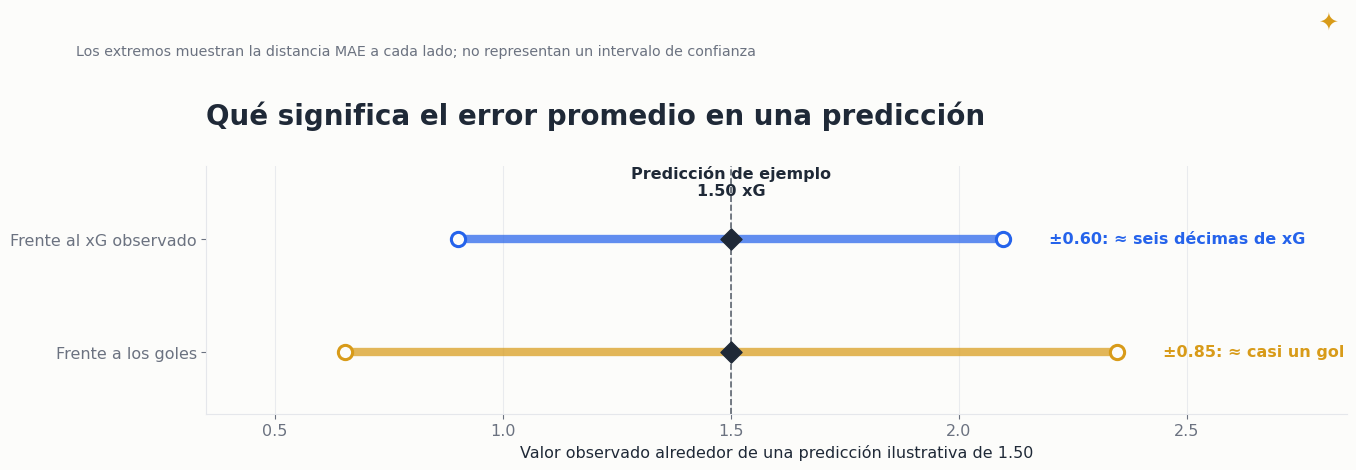

In [5]:
example_prediction = 1.50
model_xg_mae = metrics.loc["Modelo → xG", "MAE"]
model_goal_mae = metrics.loc["Modelo → goles", "MAE"]

mae_examples = [
    ("Frente al xG observado", model_xg_mae, BLUE, "≈ seis décimas de xG"),
    ("Frente a los goles", model_goal_mae, GOLD, "≈ casi un gol"),
]

fig, ax = plt.subplots(figsize=(13.8, 4.8))
for y, (label, distance, color, plain_text) in zip([1, 0], mae_examples):
    low, high = example_prediction - distance, example_prediction + distance
    ax.plot([low, high], [y, y], color=color, linewidth=6, solid_capstyle="round", alpha=0.72)
    ax.scatter([low, high], [y, y], s=105, facecolor=PAPER, edgecolor=color, linewidth=2.2, zorder=3)
    ax.scatter(example_prediction, y, s=115, color=INK, marker="D", zorder=4)
    ax.text(high + 0.10, y, f"±{distance:.2f}: {plain_text}", va="center", color=color, fontweight="bold")

ax.axvline(example_prediction, color=INK, linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(example_prediction, 1.36, "Predicción de ejemplo\n1.50 xG", ha="center", va="bottom", color=INK, fontweight="bold")
ax.set_yticks([1, 0], [item[0] for item in mae_examples])
ax.set_xlim(0.35, 2.85)
ax.set_ylim(-0.55, 1.65)
ax.set_xlabel("Valor observado alrededor de una predicción ilustrativa de 1.50")
ax.set_title("Qué significa el error promedio en una predicción", loc="left", fontsize=20, pad=30)
clean_axes(ax, grid_axis="x")

finish_chart(fig, "Los extremos muestran la distancia MAE a cada lado; no representan un intervalo de confianza", y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

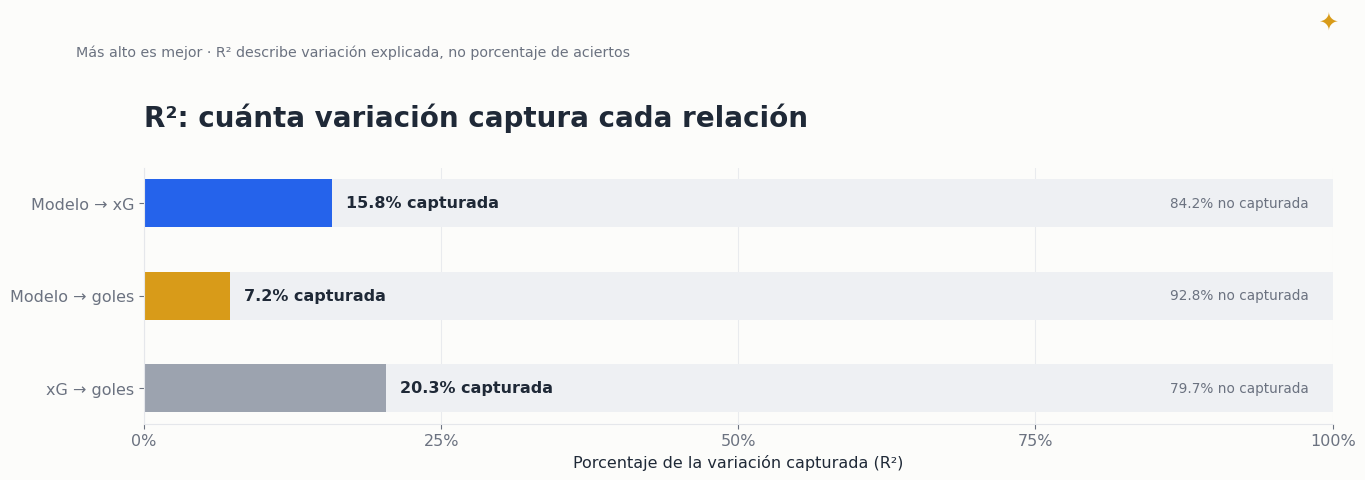

In [6]:
r2_percent = metrics["R²"] * 100
r2_colors = [BLUE, GOLD, GREY]

fig, ax = plt.subplots(figsize=(13.8, 4.9))
ax.barh(y_positions, np.full(len(y_positions), 100), color="#EEF0F3", height=0.52)
bars = ax.barh(y_positions, r2_percent.to_numpy(), color=r2_colors, height=0.52)

for bar, value in zip(bars, r2_percent):
    center_y = bar.get_y() + bar.get_height() / 2
    ax.text(value + 1.2, center_y, f"{value:.1f}% capturada", va="center", fontweight="bold")
    ax.text(98, center_y, f"{100 - value:.1f}% no capturada", va="center", ha="right", color=MUTED, fontsize=9.8)

ax.set_yticks(y_positions, comparison_labels)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("Porcentaje de la variación capturada (R²)")
ax.set_title("R²: cuánta variación captura cada relación", loc="left", fontsize=20, pad=30)
clean_axes(ax, grid_axis="x")

finish_chart(fig, "Más alto es mejor · R² describe variación explicada, no porcentaje de aciertos", y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

El modelo se aleja, en promedio, **0.60 xG** del xG observado y **0.85 goles** del marcador. Es decir: reproduce mejor la generación de ocasiones que el resultado final. El RMSE queda por encima del MAE en las tres comparaciones porque algunos errores grandes reciben más peso.

La varianza explicada se muestra aparte: **15.8%** para modelo–xG, **7.2%** para modelo–goles y **20.3%** para xG–goles. Esos porcentajes describen variación capturada; no son porcentajes de predicciones correctas.

## 4. xG observado frente a xG predicho

Cada punto es un equipo en un partido. La diagonal negra representa coincidencia exacta. Un punto **arriba** significa que el xG real fue mayor y el modelo se quedó corto; uno **abajo** significa que el modelo pronosticó de más.

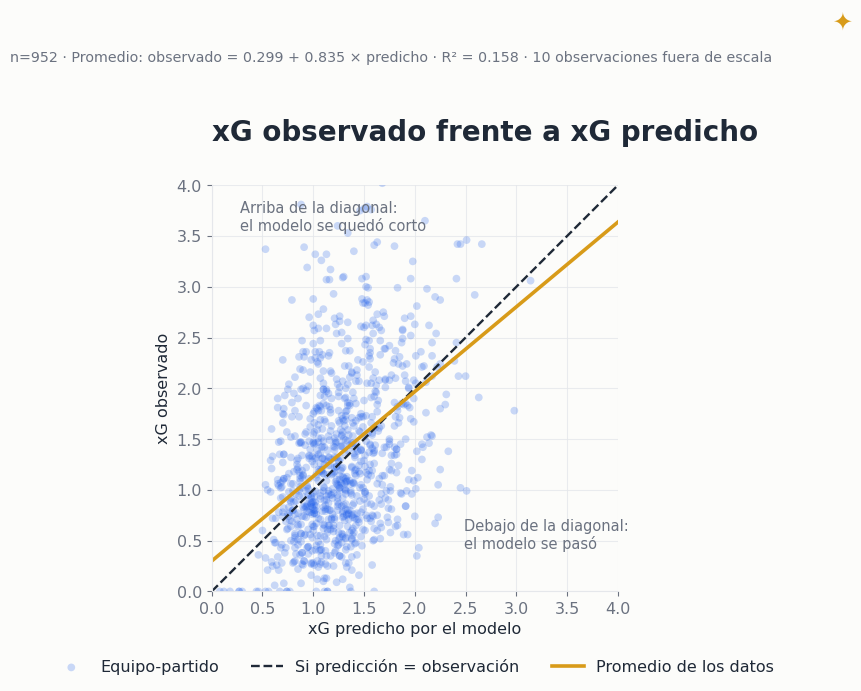

In [7]:
predicted_xg = team_observations["predicted_xg"].to_numpy()
observed_xg = team_observations["observed_xg"].to_numpy()
xg_slope, xg_intercept = np.polyfit(predicted_xg, observed_xg, 1)
xg_r2 = metrics.loc["Modelo → xG", "R²"]

axis_limit = 4.0
out_of_view = int(((predicted_xg > axis_limit) | (observed_xg > axis_limit)).sum())
fit_x = np.linspace(0, axis_limit, 200)

fig, ax = plt.subplots(figsize=(9.2, 8.0))
ax.scatter(predicted_xg, observed_xg, s=31, color=BLUE, alpha=0.24, edgecolors="none", label="Equipo-partido")
ax.plot([0, axis_limit], [0, axis_limit], color=INK, linestyle="--", linewidth=1.7, label="Si predicción = observación")
ax.plot(fit_x, xg_intercept + xg_slope * fit_x, color=GOLD, linewidth=2.6, label="Promedio de los datos")

ax.text(0.28, 3.55, "Arriba de la diagonal:\nel modelo se quedó corto", color=MUTED, fontsize=10.5)
ax.text(2.48, 0.42, "Debajo de la diagonal:\nel modelo se pasó", color=MUTED, fontsize=10.5)

ax.set_xlim(0, axis_limit)
ax.set_ylim(0, axis_limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("xG predicho por el modelo")
ax.set_ylabel("xG observado")
ax.set_title("xG observado frente a xG predicho", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
clean_axes(ax, grid_axis="both")

finish_chart(
    fig,
    f"n={len(team_observations):,} · Promedio: observado = {xg_intercept:.3f} + {xg_slope:.3f} × predicho · R² = {xg_r2:.3f} · {out_of_view} observaciones fuera de escala",
    y=0.91,
)
plt.tight_layout(rect=(0, 0.08, 1, 0.86))
plt.show()

### Cómo leer la línea dorada

La línea dorada no representa otra predicción: resume el promedio de los puntos azules. Por cada **1 xG adicional predicho**, el xG observado aumenta **0.835** en promedio; una calibración perfecta aumentaría 1.

La línea dorada cruza la diagonal cerca de **1.81 xG**. Antes de ese punto queda ligeramente arriba —el modelo suele quedarse corto— y después queda debajo —suele pasarse—. Es una tendencia del conjunto, no una regla para cada partido.

## 5. ¿Cómo se reparten los errores?

El error firmado es `xG observado − xG predicho`. Los valores negativos indican que el modelo pronosticó de más; los positivos, que se quedó corto. Aquí interesa la forma completa de la distribución, no dividirla artificialmente por nivel pronosticado.

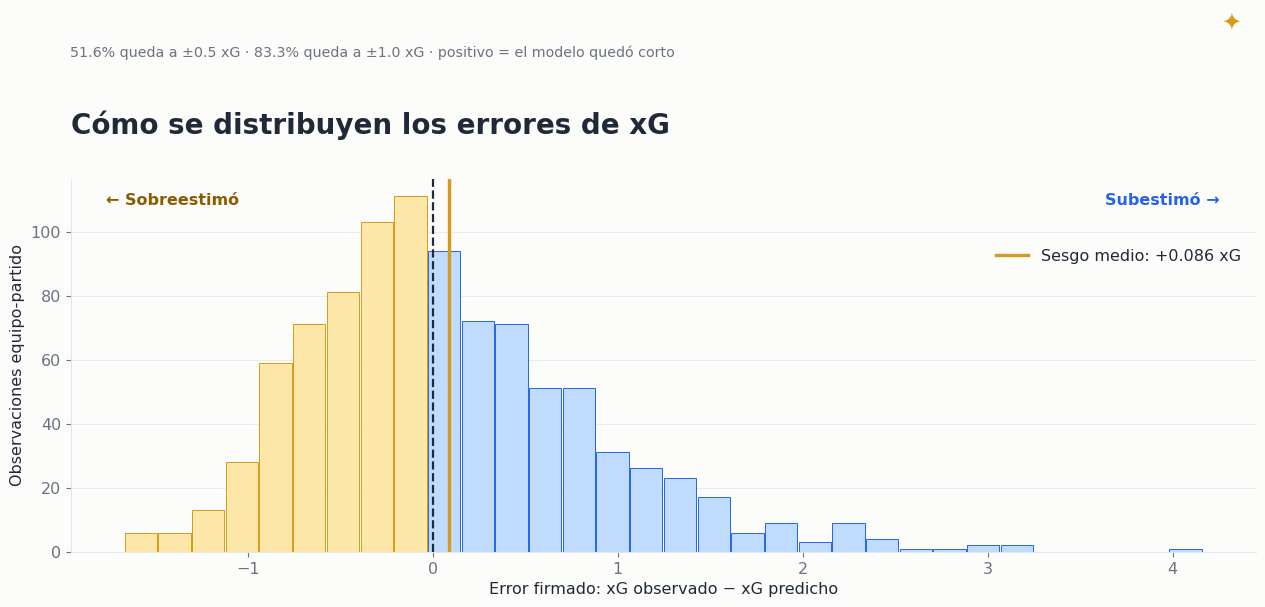

In [8]:
team_observations["xg_residual"] = team_observations["observed_xg"] - team_observations["predicted_xg"]
mean_residual = team_observations["xg_residual"].mean()
within_half_xg = team_observations["xg_residual"].abs().le(0.5).mean()
within_one_xg = team_observations["xg_residual"].abs().le(1.0).mean()

counts, bins = np.histogram(team_observations["xg_residual"], bins=32)
centers = (bins[:-1] + bins[1:]) / 2
widths = np.diff(bins)
colors = [GOLD_LIGHT if center < 0 else BLUE_LIGHT for center in centers]
edges = [GOLD if center < 0 else BLUE for center in centers]

fig, ax = plt.subplots(figsize=(12.8, 6.2))
ax.bar(centers, counts, width=widths * 0.96, color=colors, edgecolor=edges, linewidth=0.7)
ax.axvline(0, color=INK, linestyle="--", linewidth=1.6)
ax.axvline(mean_residual, color=GOLD, linewidth=2.4, label=f"Sesgo medio: {mean_residual:+.3f} xG")

ax.text(0.03, 0.93, "← Sobreestimó", transform=ax.transAxes, color="#8A5C00", fontweight="bold")
ax.text(0.97, 0.93, "Subestimó →", transform=ax.transAxes, color=BLUE, fontweight="bold", ha="right")
ax.set_xlabel("Error firmado: xG observado − xG predicho")
ax.set_ylabel("Observaciones equipo-partido")
ax.set_title("Cómo se distribuyen los errores de xG", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.85))
clean_axes(ax, grid_axis="y")

finish_chart(
    fig,
    f"{within_half_xg:.1%} queda a ±0.5 xG · {within_one_xg:.1%} queda a ±1.0 xG · positivo = el modelo quedó corto",
    y=0.90,
)
plt.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()

El sesgo medio es apenas **+0.086 xG**, así que no existe un desplazamiento general grande hacia un solo lado. Además, **51.6%** de las observaciones queda a medio xG o menos y **83.3%** queda a un xG o menos. La cola a ambos lados explica por qué el RMSE es mayor que el MAE.

## 6. Goles observados frente a xG predicho

Los goles solo pueden tomar valores enteros, por lo que los puntos forman franjas horizontales. Para hacer visible la calibración sin esconder los partidos individuales, superponemos el promedio de goles dentro de diez grupos de igual tamaño ordenados por xG predicho.

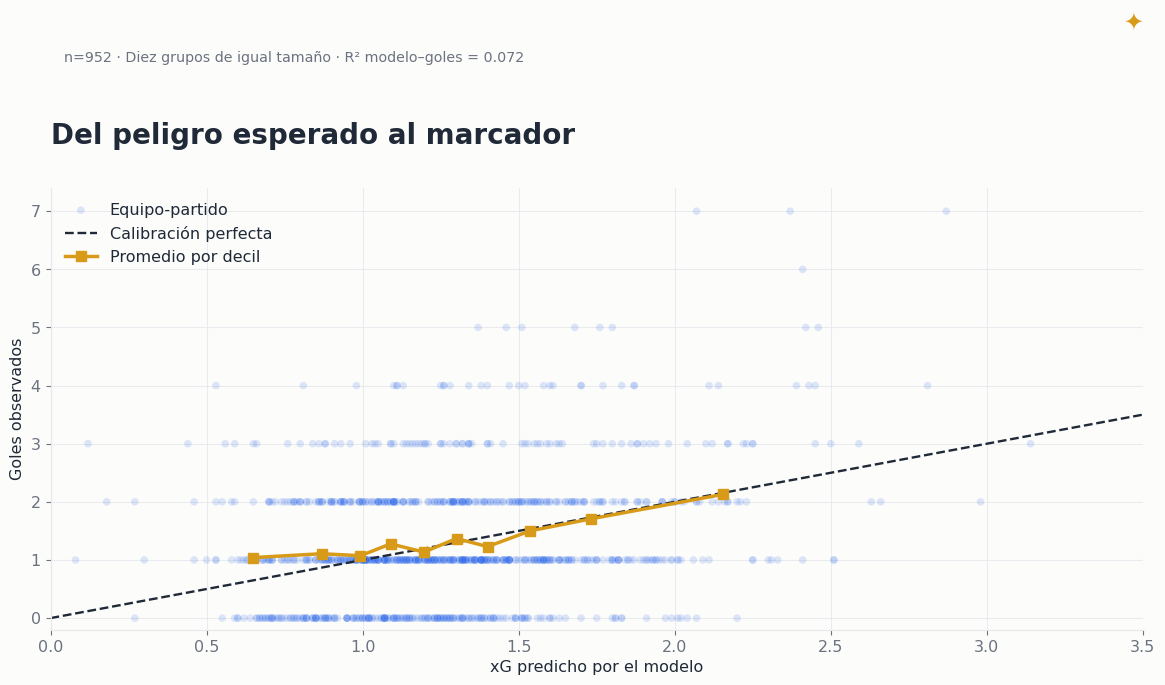

In [9]:
team_observations["goal_calibration_decile"] = pd.qcut(
    team_observations["predicted_xg"], q=10, duplicates="drop"
)
goal_calibration = (
    team_observations
    .groupby("goal_calibration_decile", observed=False)
    .agg(
        mean_predicted_xg=("predicted_xg", "mean"),
        mean_goals=("observed_goals", "mean"),
        observations=("match_id", "size"),
    )
    .reset_index(drop=True)
)

goal_r2 = metrics.loc["Modelo → goles", "R²"]
x_limit = np.ceil(team_observations["predicted_xg"].max() * 2) / 2
y_limit = int(team_observations["observed_goals"].max()) + 0.4

fig, ax = plt.subplots(figsize=(11.8, 7.0))
ax.scatter(
    team_observations["predicted_xg"],
    team_observations["observed_goals"],
    s=30,
    color=BLUE,
    alpha=0.15,
    edgecolors="none",
    label="Equipo-partido",
)
ax.plot([0, x_limit], [0, x_limit], color=INK, linestyle="--", linewidth=1.7, label="Calibración perfecta")
ax.plot(
    goal_calibration["mean_predicted_xg"],
    goal_calibration["mean_goals"],
    color=GOLD,
    marker="s",
    markersize=7,
    linewidth=2.5,
    label="Promedio por decil",
)

ax.set_xlim(0, x_limit)
ax.set_ylim(-0.2, y_limit)
ax.set_xlabel("xG predicho por el modelo")
ax.set_ylabel("Goles observados")
ax.set_title("Del peligro esperado al marcador", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="upper left")
clean_axes(ax, grid_axis="both")

finish_chart(fig, f"n={len(team_observations):,} · Diez grupos de igual tamaño · R² modelo–goles = {goal_r2:.3f}", y=0.90)
plt.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()

La curva dorada permite leer la relación promedio sin fingir que cada partido debería caer exactamente sobre la diagonal. Los puntos permanecen visibles para mostrar cuánto puede variar el marcador incluso entre equipos con expectativas parecidas.

## 7. Qué nos llevamos

- El modelo se acerca más al **xG observado** que a los goles: MAE de **0.598** frente a **0.847**.
- La comparación modelo–xG alcanza R² **0.158**; frente a goles baja a **0.072**, consistente con el ruido adicional del marcador.
- El propio xG observado tampoco reproduce perfectamente los goles: su MAE es **0.785** y su R² **0.203**. Esta referencia pone en contexto el límite de una predicción prepartido.
- RMSE supera al MAE en las tres comparaciones, señal de que una parte del error proviene de casos grandes y no de una desviación uniforme.
- La pendiente de calibración modelo–xG es menor que 1 y el residuo medio es ligeramente positivo; conviene revisar la compresión de predicciones bajas y altas antes de interpretar solo el promedio.

El siguiente notebook transforma estas distribuciones de goles esperados en probabilidades de mercado; aquí dejamos aislada la calidad de la predicción base.

## Checks de reproducibilidad

- Fuente congelada: `02_data/predictions.xlsx`, hoja `Sheet1`.
- Muestra original: 485 partidos; muestra completa: 476 partidos y 952 observaciones equipo-partido.
- Exclusión: nueve partidos sin xG observado para uno o ambos equipos.
- Ejemplos: diez partidos sin reemplazo con `random_state=42`.
- Métricas: `sklearn.metrics`, con el valor observado como `y_true` y la estimación como `y_pred`.
- Calibración y residuos: diez grupos de igual frecuencia calculados con `pandas.qcut`.
- El notebook no abre conexiones SQL, no utiliza credenciales y no necesita red.

In [10]:
expected_metrics = pd.DataFrame(
    {
        "MAE": [0.598, 0.847, 0.785],
        "RMSE": [0.786, 1.090, 1.010],
        "R²": [0.158, 0.072, 0.203],
    },
    index=["Modelo → xG", "Modelo → goles", "xG → goles"],
)

assert len(raw_predictions) == 485
assert len(complete_predictions) == 476
assert len(team_observations) == 952
assert len(example_matches) == 10
assert example_matches["match_id"].nunique() == 10
assert len(goal_calibration) == 10
assert np.allclose(metrics.loc[expected_metrics.index, expected_metrics.columns], expected_metrics, atol=5e-4)
assert np.isclose(within_half_xg, 0.5157563025)
assert np.isclose(within_one_xg, 0.8329831933)

print("✓ Datos, muestra aleatoria, métricas y calibración verificados.")

✓ Datos, muestra aleatoria, métricas y calibración verificados.
